# 04 — Modeling: Hedonic Pricing vs Machine Learning
### European Used Car Price Prediction (2023–2025)

**Pipeline:**
1. Load feature-engineered data + metadata
2. Stratified random split 70/15/15 (train/val/test)
3. Preprocessing: SimpleImputer(median) + RobustScaler
4. Baselines: Global Mean, Country Mean
5. Hedonic models: OLS, Ridge, Lasso, ElasticNet (GridSearchCV)
6. ML models: Random Forest, LightGBM, XGBoost (RandomizedSearchCV)
7. Comprehensive evaluation & visualization
8. Leave-one-year-out robustness check
9. Save artifacts

In [1]:
import sys, warnings, json, time
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
import lightgbm as lgb
import xgboost as xgb
import joblib

from config import (
    DATA_PROC, FIGURES, MODELS_DIR, RANDOM_STATE,
    LOG_TARGET, TARGET_COL, TRAIN_RATIO, VAL_RATIO, TEST_RATIO,
    STRATIFY_COLS, DATA_YEARS
)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Feature Metadata

In [2]:
df = pd.read_parquet(DATA_PROC / 'features_engineered.parquet')
with open(DATA_PROC / 'feature_metadata.json') as f:
    feat_meta = json.load(f)

ml_features = feat_meta['ml_features']
hedonic_features = feat_meta['hedonic_features']
target = feat_meta['target']

print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'ML features ({len(ml_features)}):      {ml_features}')
print(f'Hedonic features ({len(hedonic_features)}): {hedonic_features}')
print(f'Target: {target}')
print(f'\nYear distribution:')
print(df['data_year'].value_counts().sort_index())
print(f'\nPowertrain distribution:')
print(df['powertrain'].value_counts())

Dataset: 228,870 rows x 86 cols
ML features (23):      ['log_mileage', 'vehicle_age', 'power_hp', 'data_year', 'mileage_per_year', 'power_per_age', 'make_encoded', 'model_encoded', 'body_encoded', 'transmission_encoded', 'drive_encoded', 'electrification_score', 'condition_encoded', 'is_ev', 'is_phev', 'is_ice', 'is_neutral_color', 'country_fe', 'doors', 'electric_range_km', 'has_electric_range', 'battery_cost_index', 'eq_bool_total']
Hedonic features (29): ['log_mileage', 'vehicle_age', 'power_hp', 'data_year', 'mileage_per_year', 'power_per_age', 'make_encoded', 'model_encoded', 'body_encoded', 'transmission_encoded', 'drive_encoded', 'electrification_score', 'condition_encoded', 'is_ev', 'is_phev', 'is_ice', 'is_neutral_color', 'country_fe', 'doors', 'electric_range_km', 'has_electric_range', 'battery_cost_index', 'eq_bool_total', 'age_x_mileage', 'age_squared', 'mileage_squared', 'ev_x_year', 'power_x_trans', 'make_x_age']
Target: log_price

Year distribution:
data_year
2023     86

## 2. Stratified Train / Validation / Test Split (70/15/15)

Primary evaluation: stratified random split preserving year, country, and make distributions.
Same stratification key and `random_state=42` as notebook 03.

In [3]:
# Re-create stratification key (same logic as notebook 03)
if '_strat' not in df.columns:
    df['_strat'] = (
        df['country_code'].astype(str) + '_' +
        df['make_grouped'].astype(str) + '_' +
        df['data_year'].astype(str)
    )

# Collapse rare strata (< 5 samples) to prevent split failures
strat_counts = df['_strat'].value_counts()
rare_strata = strat_counts[strat_counts < 5].index
df.loc[df['_strat'].isin(rare_strata), '_strat'] = 'rare_stratum'
print(f'Unique strata: {df["_strat"].nunique()} (collapsed {len(rare_strata)} rare strata)')

# Step 1: train+val vs test (85 / 15)
df_trainval, df_test = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE,
    stratify=df['_strat']
)

# Step 2: train vs val from trainval  (70/15 -> ~82.35/17.65 of trainval)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_frac, random_state=RANDOM_STATE,
    stratify=df_trainval['_strat']
)

print(f'\nTrain: {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val:   {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test:  {len(df_test):,}  ({len(df_test)/len(df)*100:.1f}%)')

# Verify stratification preserved year distributions
print('\nYear distributions per split:')
for name, subset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    yr_pct = subset['data_year'].value_counts(normalize=True).sort_index()
    print(f'  {name}: {dict(yr_pct.round(3))}')

Unique strata: 483 (collapsed 57 rare strata)

Train: 160,208 (70.0%)
Val:   34,331  (15.0%)
Test:  34,331  (15.0%)

Year distributions per split:
  Train: {2023: np.float64(0.376), 2024: np.float64(0.153), 2025: np.float64(0.471)}
  Val: {2023: np.float64(0.376), 2024: np.float64(0.153), 2025: np.float64(0.471)}
  Test: {2023: np.float64(0.376), 2024: np.float64(0.153), 2025: np.float64(0.471)}


In [4]:
# Extract feature matrices and targets
X_train_ml  = df_train[ml_features].copy()
X_val_ml    = df_val[ml_features].copy()
X_test_ml   = df_test[ml_features].copy()

X_train_hed = df_train[hedonic_features].copy()
X_val_hed   = df_val[hedonic_features].copy()
X_test_hed  = df_test[hedonic_features].copy()

y_train = df_train[target].values
y_val   = df_val[target].values
y_test  = df_test[target].values

# Keep price_eur for MAE in EUR calculation
price_train = df_train[TARGET_COL].values
price_val   = df_val[TARGET_COL].values
price_test  = df_test[TARGET_COL].values

print(f'X_train_ml:  {X_train_ml.shape}')
print(f'X_train_hed: {X_train_hed.shape}')
print(f'y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]')

X_train_ml:  (160208, 23)
X_train_hed: (160208, 29)
y_train range: [7.00, 12.49]


## 3. Preprocessing: SimpleImputer(median) + RobustScaler

Fit on training data only to prevent data leakage.

In [5]:
# ML preprocessor
imputer_ml = SimpleImputer(strategy='median')
scaler_ml  = RobustScaler()

X_train_ml_imp = imputer_ml.fit_transform(X_train_ml)
X_val_ml_imp   = imputer_ml.transform(X_val_ml)
X_test_ml_imp  = imputer_ml.transform(X_test_ml)

X_train_ml_sc = scaler_ml.fit_transform(X_train_ml_imp)
X_val_ml_sc   = scaler_ml.transform(X_val_ml_imp)
X_test_ml_sc  = scaler_ml.transform(X_test_ml_imp)

# Hedonic preprocessor (different feature set, includes interactions)
imputer_hed = SimpleImputer(strategy='median')
scaler_hed  = RobustScaler()

X_train_hed_imp = imputer_hed.fit_transform(X_train_hed)
X_val_hed_imp   = imputer_hed.transform(X_val_hed)
X_test_hed_imp  = imputer_hed.transform(X_test_hed)

X_train_hed_sc = scaler_hed.fit_transform(X_train_hed_imp)
X_val_hed_sc   = scaler_hed.transform(X_val_hed_imp)
X_test_hed_sc  = scaler_hed.transform(X_test_hed_imp)

print(f'Preprocessed ML:      {X_train_ml_sc.shape}')
print(f'Preprocessed Hedonic: {X_train_hed_sc.shape}')
print(f'NaN remaining (ML train): {np.isnan(X_train_ml_imp).sum()}')

Preprocessed ML:      (160208, 23)
Preprocessed Hedonic: (160208, 29)
NaN remaining (ML train): 0


## Evaluation Helpers

In [6]:
def evaluate_model(y_true, y_pred, price_actual, split_name=''):
    """Evaluate log-price predictions; also compute MAE in EUR."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    pred_eur = np.exp(y_pred)
    mae_eur  = np.mean(np.abs(price_actual - pred_eur))
    return {
        'Split': split_name, 'RMSE_log': round(rmse, 4),
        'MAE_log': round(mae, 4), 'MAPE_%': round(mape, 2),
        'R\u00b2': round(r2, 4), 'MAE_EUR': round(mae_eur)
    }


def fit_and_evaluate(model, name, X_tr, X_v, X_te, y_tr, y_v, y_te,
                     price_v, price_te, category=''):
    """Fit model, predict on val+test, return results list."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    pred_val  = model.predict(X_v)
    pred_test = model.predict(X_te)

    res_val  = evaluate_model(y_v, pred_val, price_v, 'Val')
    res_test = evaluate_model(y_te, pred_test, price_te, 'Test')

    for r in [res_val, res_test]:
        r['Model'] = name
        r['Category'] = category

    print(f'{name:20s} | Val  RMSE={res_val["RMSE_log"]:.4f}  R\u00b2={res_val["R\u00b2"]:.4f} '
          f'| Test RMSE={res_test["RMSE_log"]:.4f}  R\u00b2={res_test["R\u00b2"]:.4f} '
          f'| {elapsed:.1f}s')
    return [res_val, res_test], model, pred_val, pred_test


# Storage
all_results = []
models_dict = {}
predictions = {}   # name -> (pred_val, pred_test)
print('Evaluation helpers ready.')

Evaluation helpers ready.


## 4. Baselines: Global Mean & Country Mean

In [7]:
# Baseline 1: Global Mean
global_mean = y_train.mean()
pred_gm_val  = np.full(len(y_val), global_mean)
pred_gm_test = np.full(len(y_test), global_mean)

res_gm_val  = evaluate_model(y_val, pred_gm_val, price_val, 'Val')
res_gm_test = evaluate_model(y_test, pred_gm_test, price_test, 'Test')
for r in [res_gm_val, res_gm_test]:
    r['Model'] = 'Global Mean'
    r['Category'] = 'Baseline'
all_results.extend([res_gm_val, res_gm_test])
predictions['Global Mean'] = (pred_gm_val, pred_gm_test)

print(f'Global Mean: train mean log_price = {global_mean:.4f}')
print(f'  Val:  RMSE={res_gm_val["RMSE_log"]:.4f}  R\u00b2={res_gm_val["R\u00b2"]:.4f}  MAE=\u20ac{res_gm_val["MAE_EUR"]:,.0f}')
print(f'  Test: RMSE={res_gm_test["RMSE_log"]:.4f}  R\u00b2={res_gm_test["R\u00b2"]:.4f}  MAE=\u20ac{res_gm_test["MAE_EUR"]:,.0f}')

# Baseline 2: Country Mean
country_means = df_train.groupby('country_code')[target].mean()
pred_cm_val  = df_val['country_code'].map(country_means).fillna(global_mean).values
pred_cm_test = df_test['country_code'].map(country_means).fillna(global_mean).values

res_cm_val  = evaluate_model(y_val, pred_cm_val, price_val, 'Val')
res_cm_test = evaluate_model(y_test, pred_cm_test, price_test, 'Test')
for r in [res_cm_val, res_cm_test]:
    r['Model'] = 'Country Mean'
    r['Category'] = 'Baseline'
all_results.extend([res_cm_val, res_cm_test])
predictions['Country Mean'] = (pred_cm_val, pred_cm_test)

print(f'\nCountry Mean:')
print(f'  Val:  RMSE={res_cm_val["RMSE_log"]:.4f}  R\u00b2={res_cm_val["R\u00b2"]:.4f}  MAE=\u20ac{res_cm_val["MAE_EUR"]:,.0f}')
print(f'  Test: RMSE={res_cm_test["RMSE_log"]:.4f}  R\u00b2={res_cm_test["R\u00b2"]:.4f}  MAE=\u20ac{res_cm_test["MAE_EUR"]:,.0f}')

Global Mean: train mean log_price = 10.2716
  Val:  RMSE=1.1002  R²=-0.0001  MAE=€31,695
  Test: RMSE=1.1014  R²=-0.0000  MAE=€31,416

Country Mean:
  Val:  RMSE=1.0735  R²=0.0478  MAE=€31,288
  Test: RMSE=1.0735  R²=0.0500  MAE=€31,015


## 5. Hedonic Models: OLS, Ridge, Lasso, ElasticNet

Classical hedonic pricing approach with interaction terms and regularisation.
All use scaled hedonic feature set (28 features including interaction terms).

In [8]:
# 5a. OLS (Hedonic Baseline)
ols = LinearRegression()
res_ols, ols_fitted, pred_ols_v, pred_ols_t = fit_and_evaluate(
    ols, 'OLS (Hedonic)', X_train_hed_sc, X_val_hed_sc, X_test_hed_sc,
    y_train, y_val, y_test, price_val, price_test, 'Hedonic'
)
all_results.extend(res_ols)
models_dict['OLS (Hedonic)'] = ols_fitted
predictions['OLS (Hedonic)'] = (pred_ols_v, pred_ols_t)

OLS (Hedonic)        | Val  RMSE=0.7068  R²=0.5873 | Test RMSE=0.7093  R²=0.5852 | 0.0s


In [9]:
# 5b. Ridge (GridSearchCV, cv=5)
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
ridge_cv = GridSearchCV(
    Ridge(), ridge_params, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
res_ridge, ridge_fitted, pred_ridge_v, pred_ridge_t = fit_and_evaluate(
    ridge_cv, 'Ridge', X_train_hed_sc, X_val_hed_sc, X_test_hed_sc,
    y_train, y_val, y_test, price_val, price_test, 'Hedonic'
)
all_results.extend(res_ridge)
models_dict['Ridge'] = ridge_fitted.best_estimator_
predictions['Ridge'] = (pred_ridge_v, pred_ridge_t)
print(f'  Best alpha: {ridge_fitted.best_params_["alpha"]}')

Ridge                | Val  RMSE=0.7068  R²=0.5873 | Test RMSE=0.7093  R²=0.5852 | 2.3s
  Best alpha: 0.001


In [10]:
# 5c. Lasso (GridSearchCV, cv=5)
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_cv = GridSearchCV(
    Lasso(max_iter=10000), lasso_params, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
res_lasso, lasso_fitted, pred_lasso_v, pred_lasso_t = fit_and_evaluate(
    lasso_cv, 'Lasso', X_train_hed_sc, X_val_hed_sc, X_test_hed_sc,
    y_train, y_val, y_test, price_val, price_test, 'Hedonic'
)
all_results.extend(res_lasso)
models_dict['Lasso'] = lasso_fitted.best_estimator_
predictions['Lasso'] = (pred_lasso_v, pred_lasso_t)
print(f'  Best alpha: {lasso_fitted.best_params_["alpha"]}')

Lasso                | Val  RMSE=0.7067  R²=0.5873 | Test RMSE=0.7094  R²=0.5852 | 29.4s
  Best alpha: 0.0001


In [11]:
# 5d. ElasticNet (GridSearchCV, cv=5)
enet_params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
enet_cv = GridSearchCV(
    ElasticNet(max_iter=10000), enet_params, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
res_enet, enet_fitted, pred_enet_v, pred_enet_t = fit_and_evaluate(
    enet_cv, 'ElasticNet', X_train_hed_sc, X_val_hed_sc, X_test_hed_sc,
    y_train, y_val, y_test, price_val, price_test, 'Hedonic'
)
all_results.extend(res_enet)
models_dict['ElasticNet'] = enet_fitted.best_estimator_
predictions['ElasticNet'] = (pred_enet_v, pred_enet_t)
print(f'  Best params: {enet_fitted.best_params_}')

ElasticNet           | Val  RMSE=0.7067  R²=0.5873 | Test RMSE=0.7094  R²=0.5852 | 118.7s
  Best params: {'alpha': 0.0001, 'l1_ratio': 0.9}


## 6. Random Forest (RandomizedSearchCV, n_iter=15, cv=3)

In [12]:
rf_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [None, 15, 20, 30, 40],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [0.3, 0.5, 0.7, 'sqrt'],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist, n_iter=15, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

# Tree-based models use imputed but NOT scaled data
res_rf, rf_fitted, pred_rf_v, pred_rf_t = fit_and_evaluate(
    rf_search, 'Random Forest', X_train_ml_imp, X_val_ml_imp, X_test_ml_imp,
    y_train, y_val, y_test, price_val, price_test, 'ML'
)
all_results.extend(res_rf)
models_dict['Random Forest'] = rf_fitted.best_estimator_
predictions['Random Forest'] = (pred_rf_v, pred_rf_t)
print(f'  Best params: {rf_fitted.best_params_}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Random Forest        | Val  RMSE=0.5323  R²=0.7659 | Test RMSE=0.5300  R²=0.7685 | 563.5s
  Best params: {'n_estimators': 700, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 20}


## 7. LightGBM (RandomizedSearchCV, n_iter=20, cv=3)

In [13]:
lgb_param_dist = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [-1, 10, 15, 20],
    'num_leaves': [31, 63, 127, 255],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'min_child_samples': [5, 10, 20, 50],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    lgb_param_dist, n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

res_lgb, lgb_fitted, pred_lgb_v, pred_lgb_t = fit_and_evaluate(
    lgb_search, 'LightGBM', X_train_ml_imp, X_val_ml_imp, X_test_ml_imp,
    y_train, y_val, y_test, price_val, price_test, 'ML'
)
all_results.extend(res_lgb)
models_dict['LightGBM'] = lgb_fitted.best_estimator_
predictions['LightGBM'] = (pred_lgb_v, pred_lgb_t)
print(f'  Best params: {lgb_fitted.best_params_}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
LightGBM             | Val  RMSE=0.5277  R²=0.7699 | Test RMSE=0.5246  R²=0.7731 | 380.5s
  Best params: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 1000, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


## 8. XGBoost (RandomizedSearchCV, n_iter=20, cv=3)

In [14]:
xgb_param_dist = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [6, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.7, 0.8],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.1, 0.3],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(
        random_state=RANDOM_STATE, tree_method='hist',
        verbosity=0, n_jobs=-1
    ),
    xgb_param_dist, n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

res_xgb, xgb_fitted, pred_xgb_v, pred_xgb_t = fit_and_evaluate(
    xgb_search, 'XGBoost', X_train_ml_imp, X_val_ml_imp, X_test_ml_imp,
    y_train, y_val, y_test, price_val, price_test, 'ML'
)
all_results.extend(res_xgb)
models_dict['XGBoost'] = xgb_fitted.best_estimator_
predictions['XGBoost'] = (pred_xgb_v, pred_xgb_t)
print(f'  Best params: {xgb_fitted.best_params_}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost              | Val  RMSE=0.5269  R²=0.7706 | Test RMSE=0.5245  R²=0.7732 | 96.2s
  Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 12, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}


## 9. Complete Model Comparison Table

In [15]:
results_df = pd.DataFrame(all_results)
results_df = results_df[['Model', 'Category', 'Split', 'RMSE_log', 'MAE_log',
                          'MAPE_%', 'R\u00b2', 'MAE_EUR']]

# Order by test RMSE
test_order = (
    results_df[results_df['Split'] == 'Test']
    .sort_values('RMSE_log')['Model'].tolist()
)

print('=' * 95)
print('COMPLETE MODEL COMPARISON  (sorted by Test RMSE)')
print('=' * 95)
for model_name in test_order:
    sub = results_df[results_df['Model'] == model_name]
    v = sub[sub['Split'] == 'Val'].iloc[0]
    t = sub[sub['Split'] == 'Test'].iloc[0]
    print(f"\n{model_name} [{t['Category']}]")
    print(f"  Val:  RMSE={v['RMSE_log']:.4f}  MAPE={v['MAPE_%']:.2f}%  "
          f"R\u00b2={v['R\u00b2']:.4f}  MAE=\u20ac{v['MAE_EUR']:,.0f}")
    print(f"  Test: RMSE={t['RMSE_log']:.4f}  MAPE={t['MAPE_%']:.2f}%  "
          f"R\u00b2={t['R\u00b2']:.4f}  MAE=\u20ac{t['MAE_EUR']:,.0f}")

# Improvement summary
best_hed_t = results_df[(results_df['Split']=='Test') & (results_df['Category']=='Hedonic')].sort_values('RMSE_log').iloc[0]
best_ml_t  = results_df[(results_df['Split']=='Test') & (results_df['Category']=='ML')].sort_values('RMSE_log').iloc[0]
improv = (best_hed_t['RMSE_log'] - best_ml_t['RMSE_log']) / best_hed_t['RMSE_log'] * 100
print(f'\n>>> ML ({best_ml_t["Model"]}) beats Hedonic ({best_hed_t["Model"]}) '
      f'by {improv:.1f}% RMSE reduction on test set.')

COMPLETE MODEL COMPARISON  (sorted by Test RMSE)

XGBoost [ML]
  Val:  RMSE=0.5269  MAPE=3.06%  R²=0.7706  MAE=€10,155
  Test: RMSE=0.5245  MAPE=3.05%  R²=0.7732  MAE=€10,048

LightGBM [ML]
  Val:  RMSE=0.5277  MAPE=3.08%  R²=0.7699  MAE=€10,314
  Test: RMSE=0.5246  MAPE=3.08%  R²=0.7731  MAE=€10,158

Random Forest [ML]
  Val:  RMSE=0.5323  MAPE=3.09%  R²=0.7659  MAE=€10,016
  Test: RMSE=0.5300  MAPE=3.09%  R²=0.7685  MAE=€9,959

OLS (Hedonic) [Hedonic]
  Val:  RMSE=0.7068  MAPE=5.44%  R²=0.5873  MAE=€19,757
  Test: RMSE=0.7093  MAPE=5.47%  R²=0.5852  MAE=€19,657

Ridge [Hedonic]
  Val:  RMSE=0.7068  MAPE=5.44%  R²=0.5873  MAE=€19,757
  Test: RMSE=0.7093  MAPE=5.47%  R²=0.5852  MAE=€19,657

Lasso [Hedonic]
  Val:  RMSE=0.7067  MAPE=5.44%  R²=0.5873  MAE=€19,748
  Test: RMSE=0.7094  MAPE=5.47%  R²=0.5852  MAE=€19,652

ElasticNet [Hedonic]
  Val:  RMSE=0.7067  MAPE=5.44%  R²=0.5873  MAE=€19,749
  Test: RMSE=0.7094  MAPE=5.47%  R²=0.5852  MAE=€19,653

Country Mean [Baseline]
  Val:  RMSE=

## 10. Side-by-Side Bar Chart (RMSE, MAPE, R², MAE_EUR)

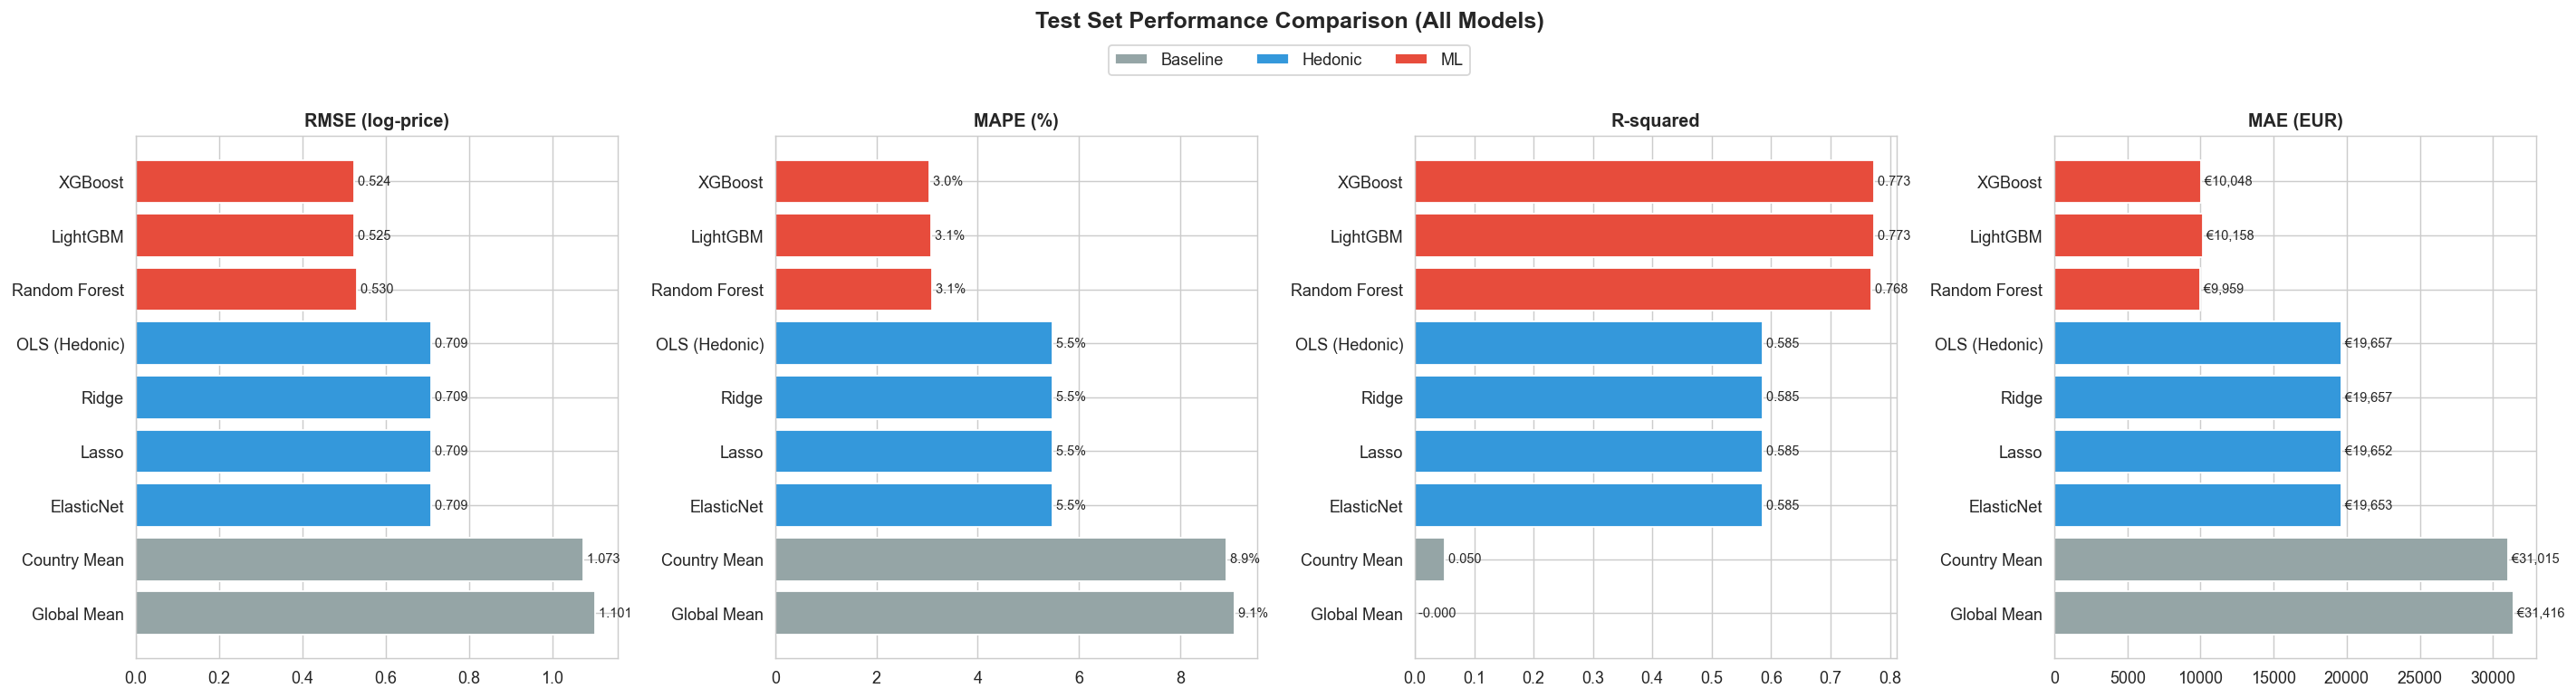

Saved: figures/04_01_model_comparison.png


In [16]:
test_res = results_df[results_df['Split'] == 'Test'].copy()
test_res = test_res.set_index('Model').loc[test_order].reset_index()

cat_colors = {'Baseline': '#95a5a6', 'Hedonic': '#3498db', 'ML': '#e74c3c'}
colors = [cat_colors[c] for c in test_res['Category']]

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
metrics = [
    ('RMSE_log', 'RMSE (log-price)', True),
    ('MAPE_%',   'MAPE (%)',         True),
    ('R\u00b2',  'R-squared',        False),
    ('MAE_EUR',  'MAE (EUR)',        True),
]

for ax, (col, title, lower_better) in zip(axes, metrics):
    bars = ax.barh(test_res['Model'], test_res[col], color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.invert_yaxis()
    for bar, val in zip(bars, test_res[col]):
        if col == 'MAE_EUR':
            fmt = f'\u20ac{val:,.0f}'
        elif col == 'MAPE_%':
            fmt = f'{val:.1f}%'
        else:
            fmt = f'{val:.3f}'
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f' {fmt}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cat_colors.items()]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.03), fontsize=10)
plt.suptitle('Test Set Performance Comparison (All Models)',
             fontweight='bold', y=1.07, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES / '04_01_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/04_01_model_comparison.png')

## 11. Per-Year Breakdown (Test Set, ML Models)

In [17]:
ml_model_names = ['Random Forest', 'LightGBM', 'XGBoost']
year_results = []

for yr in sorted(df_test['data_year'].unique()):
    mask = df_test['data_year'].values == yr
    n = mask.sum()
    print(f'\n--- {yr} (n={n:,}) ---')
    for mname in ml_model_names:
        _, pred_t = predictions[mname]
        res = evaluate_model(y_test[mask], pred_t[mask], price_test[mask], f'Test-{yr}')
        res['Model'] = mname
        res['Year'] = yr
        year_results.append(res)
        print(f"  {mname:18s}  RMSE={res['RMSE_log']:.4f}  R\u00b2={res['R\u00b2']:.4f}  "
              f"MAPE={res['MAPE_%']:.2f}%  MAE=\u20ac{res['MAE_EUR']:,.0f}")

year_df = pd.DataFrame(year_results)


--- 2023 (n=12,903) ---
  Random Forest       RMSE=0.8362  R²=0.6245  MAPE=6.39%  MAE=€18,605
  LightGBM            RMSE=0.8283  R²=0.6315  MAPE=6.31%  MAE=€18,491
  XGBoost             RMSE=0.8293  R²=0.6307  MAPE=6.33%  MAE=€18,615

--- 2024 (n=5,242) ---
  Random Forest       RMSE=0.2238  R²=0.9337  MAPE=1.48%  MAE=€5,108
  LightGBM            RMSE=0.2089  R²=0.9422  MAPE=1.43%  MAE=€5,006
  XGBoost             RMSE=0.2082  R²=0.9426  MAPE=1.39%  MAE=€4,977

--- 2025 (n=16,186) ---
  Random Forest       RMSE=0.1486  R²=0.9680  MAPE=0.98%  MAE=€4,637
  LightGBM            RMSE=0.1506  R²=0.9671  MAPE=1.03%  MAE=€5,183
  XGBoost             RMSE=0.1457  R²=0.9692  MAPE=0.98%  MAE=€4,861


## 12. Per-Powertrain Breakdown (Test Set)


--- ICE (n=28,516) ---
  Random Forest       RMSE=0.5638  R²=0.7566  MAPE=3.41%
  LightGBM            RMSE=0.5581  R²=0.7615  MAPE=3.39%
  XGBoost             RMSE=0.5579  R²=0.7617  MAPE=3.37%

--- EV (n=1,833) ---
  Random Forest       RMSE=0.4081  R²=0.7040  MAPE=2.07%
  LightGBM            RMSE=0.4001  R²=0.7156  MAPE=2.02%
  XGBoost             RMSE=0.4047  R²=0.7090  MAPE=2.02%

--- PHEV (n=3,729) ---
  Random Forest       RMSE=0.1332  R²=0.9591  MAPE=0.88%
  LightGBM            RMSE=0.1317  R²=0.9600  MAPE=0.92%
  XGBoost             RMSE=0.1286  R²=0.9618  MAPE=0.87%


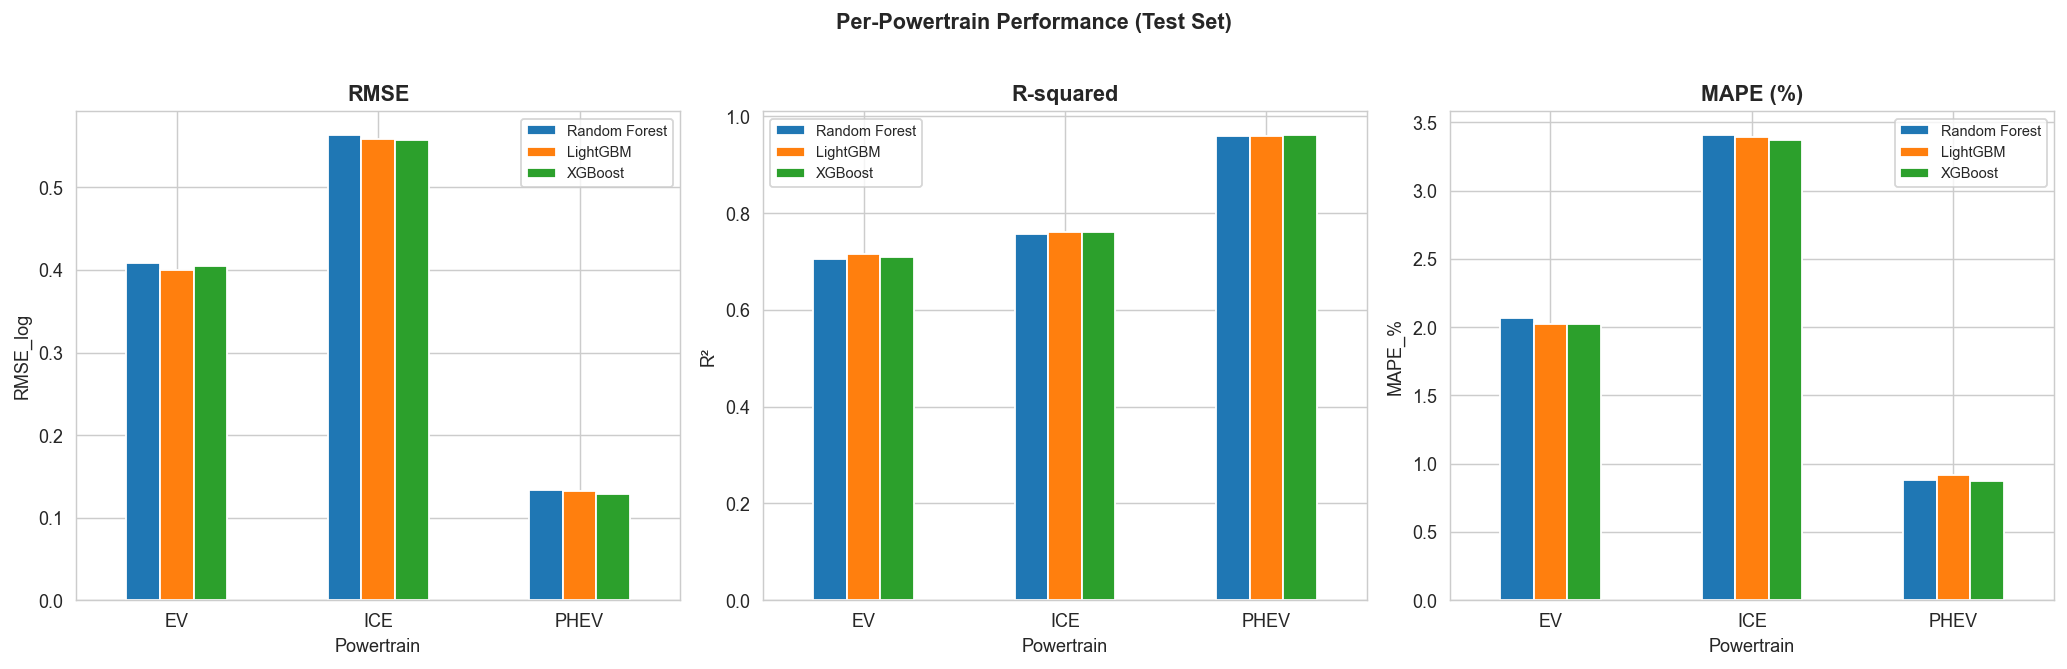

Saved: figures/04_02_powertrain_performance.png


In [18]:
pt_results = []
for pt in ['ICE', 'EV', 'PHEV']:
    mask = df_test['powertrain'].values == pt
    n_samples = mask.sum()
    if n_samples < 20:
        continue
    print(f'\n--- {pt} (n={n_samples:,}) ---')
    for mname in ml_model_names:
        _, pred_t = predictions[mname]
        res = evaluate_model(y_test[mask], pred_t[mask], price_test[mask], f'Test-{pt}')
        res['Model'] = mname
        res['Powertrain'] = pt
        res['N'] = n_samples
        pt_results.append(res)
        print(f"  {mname:18s}  RMSE={res['RMSE_log']:.4f}  R\u00b2={res['R\u00b2']:.4f}  "
              f"MAPE={res['MAPE_%']:.2f}%")

pt_df = pd.DataFrame(pt_results)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(axes,
                              ['RMSE_log', 'R\u00b2', 'MAPE_%'],
                              ['RMSE', 'R-squared', 'MAPE (%)']):
    pivot = pt_df.pivot_table(index='Powertrain', columns='Model', values=metric)
    pivot = pivot[ml_model_names]
    pivot.plot(kind='bar', ax=ax, rot=0, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)

plt.suptitle('Per-Powertrain Performance (Test Set)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '04_02_powertrain_performance.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/04_02_powertrain_performance.png')

## 13. Feature Importance (Random Forest + LightGBM Side-by-Side)

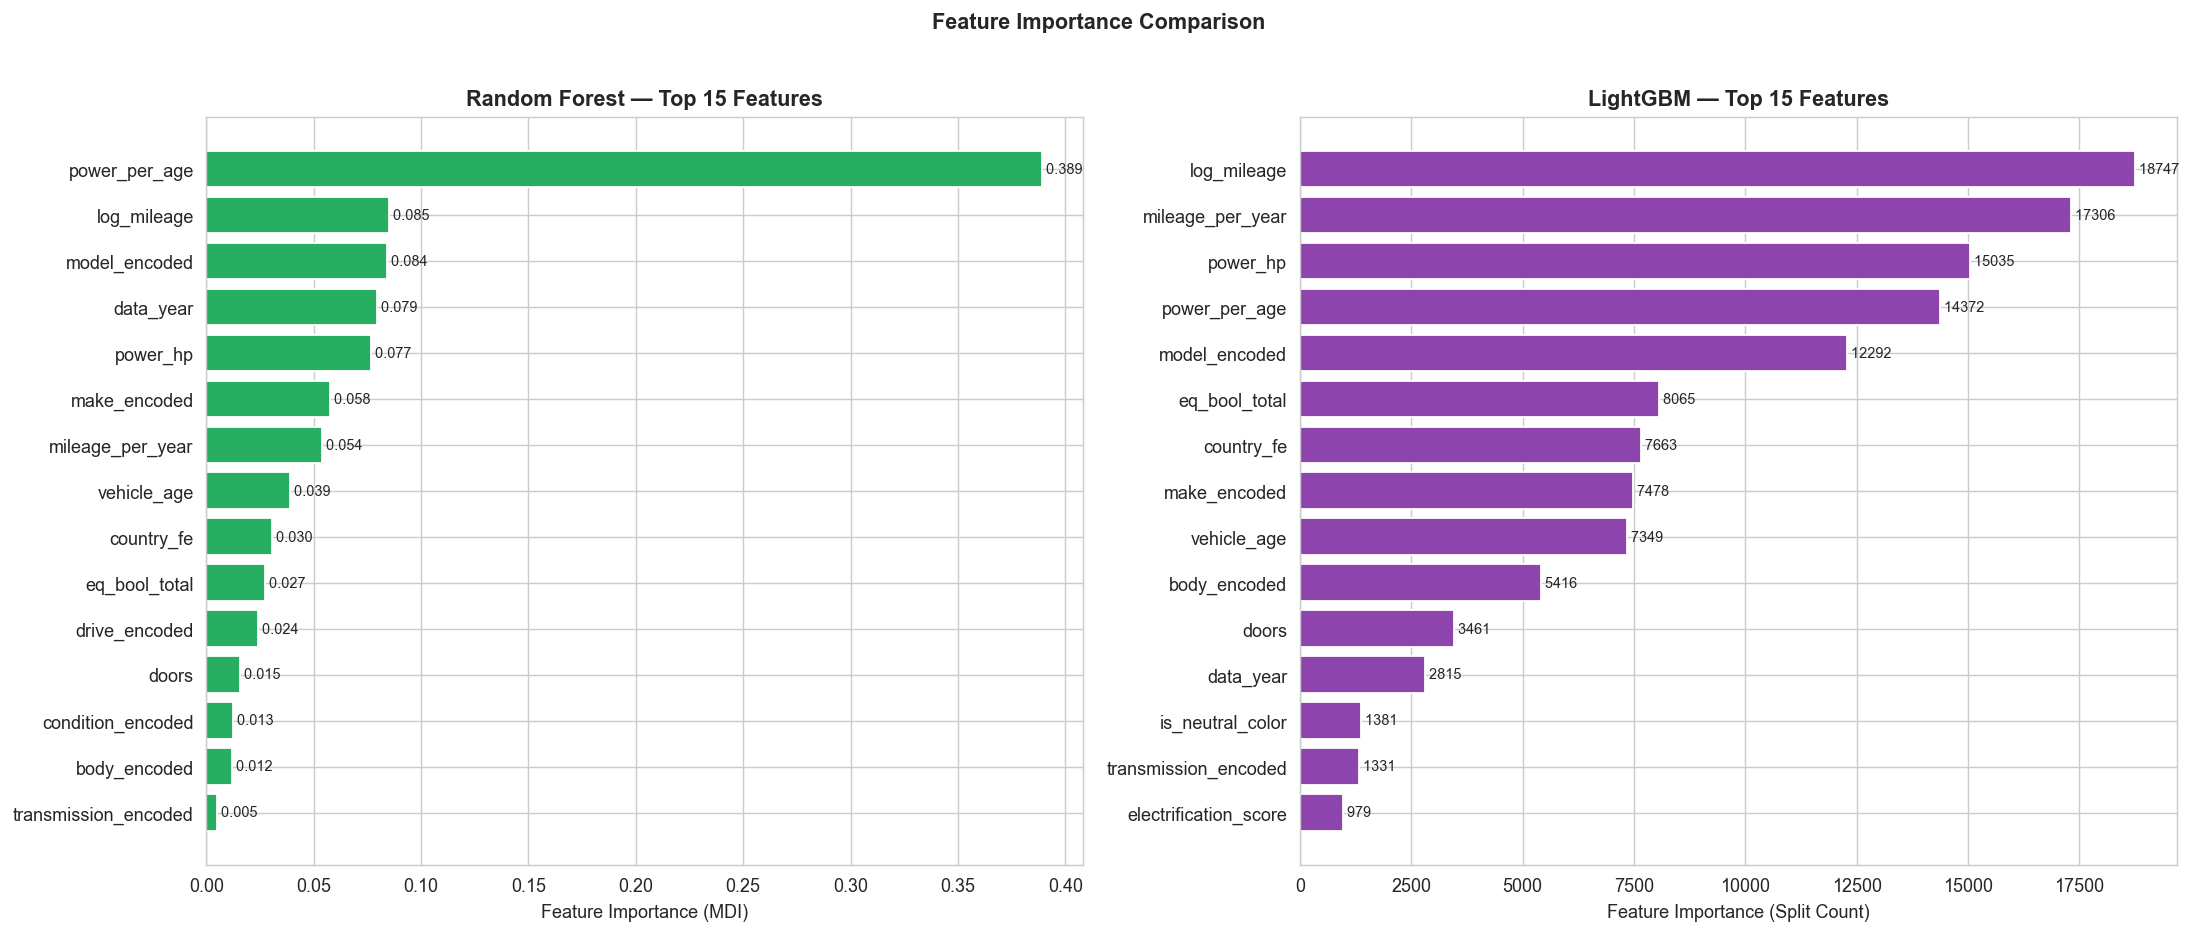

Saved: figures/04_03_feature_importance.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# RF feature importance (MDI)
rf_model = models_dict['Random Forest']
rf_imp = pd.Series(rf_model.feature_importances_, index=ml_features)
rf_top = rf_imp.nlargest(15)
axes[0].barh(rf_top.index[::-1], rf_top.values[::-1], color='#27ae60')
axes[0].set_title('Random Forest \u2014 Top 15 Features', fontweight='bold')
axes[0].set_xlabel('Feature Importance (MDI)')
for i, (feat, val) in enumerate(rf_top[::-1].items()):
    axes[0].text(val, i, f' {val:.3f}', va='center', fontsize=8)

# LightGBM feature importance (split count)
lgb_model = models_dict['LightGBM']
lgb_imp = pd.Series(lgb_model.feature_importances_, index=ml_features)
lgb_top = lgb_imp.nlargest(15)
axes[1].barh(lgb_top.index[::-1], lgb_top.values[::-1], color='#8e44ad')
axes[1].set_title('LightGBM \u2014 Top 15 Features', fontweight='bold')
axes[1].set_xlabel('Feature Importance (Split Count)')
for i, (feat, val) in enumerate(lgb_top[::-1].items()):
    axes[1].text(val, i, f' {val:.0f}', va='center', fontsize=8)

plt.suptitle('Feature Importance Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '04_03_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/04_03_feature_importance.png')

## 14. Predicted vs Actual Scatter (3 ML Models)

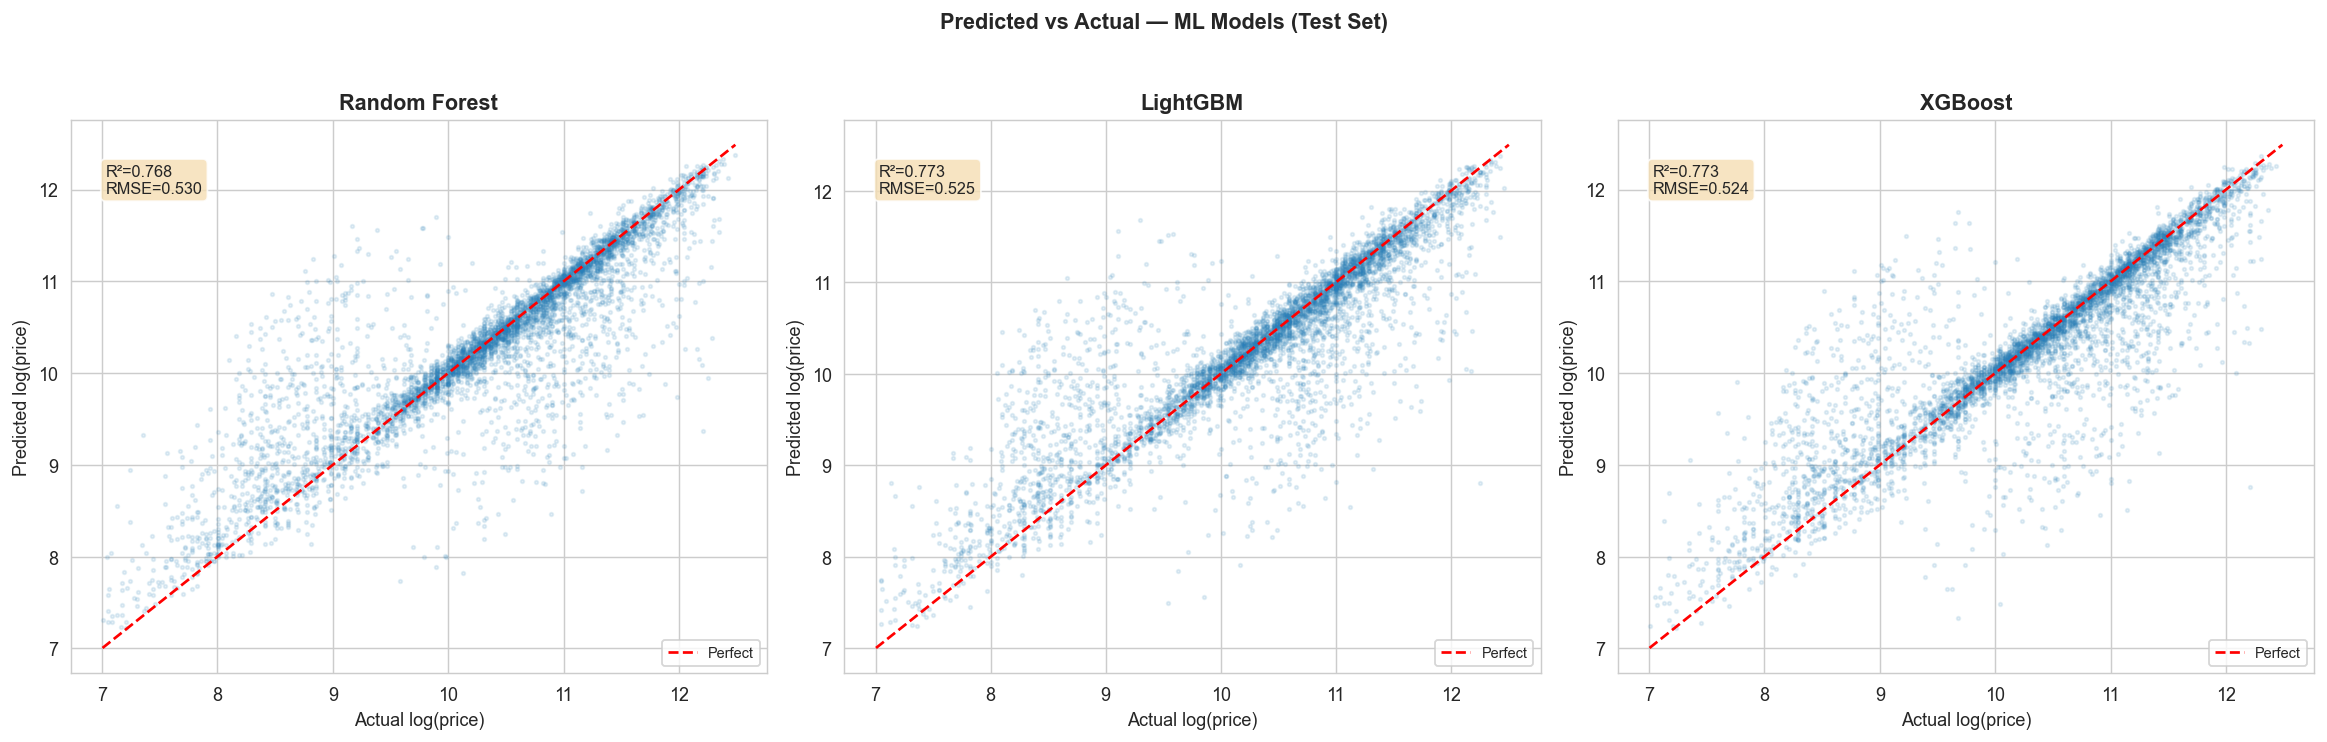

Saved: figures/04_04_pred_vs_actual.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
rng = np.random.RandomState(42)

for ax, mname in zip(axes, ml_model_names):
    _, pred_t = predictions[mname]
    n_plot = min(5000, len(y_test))
    idx = rng.choice(len(y_test), n_plot, replace=False)

    ax.scatter(y_test[idx], pred_t[idx], alpha=0.12, s=4, c='#2980b9')
    lo = min(y_test.min(), pred_t.min())
    hi = max(y_test.max(), pred_t.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect')

    r2  = r2_score(y_test, pred_t)
    rmse = np.sqrt(mean_squared_error(y_test, pred_t))
    ax.text(0.05, 0.92, f'R\u00b2={r2:.3f}\nRMSE={rmse:.3f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.set_xlabel('Actual log(price)')
    ax.set_ylabel('Predicted log(price)')
    ax.set_title(mname, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Predicted vs Actual \u2014 ML Models (Test Set)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES / '04_04_pred_vs_actual.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/04_04_pred_vs_actual.png')

## 15. Residual Analysis

Distribution, residuals vs predicted, by year, and by powertrain for the best model (XGBoost).

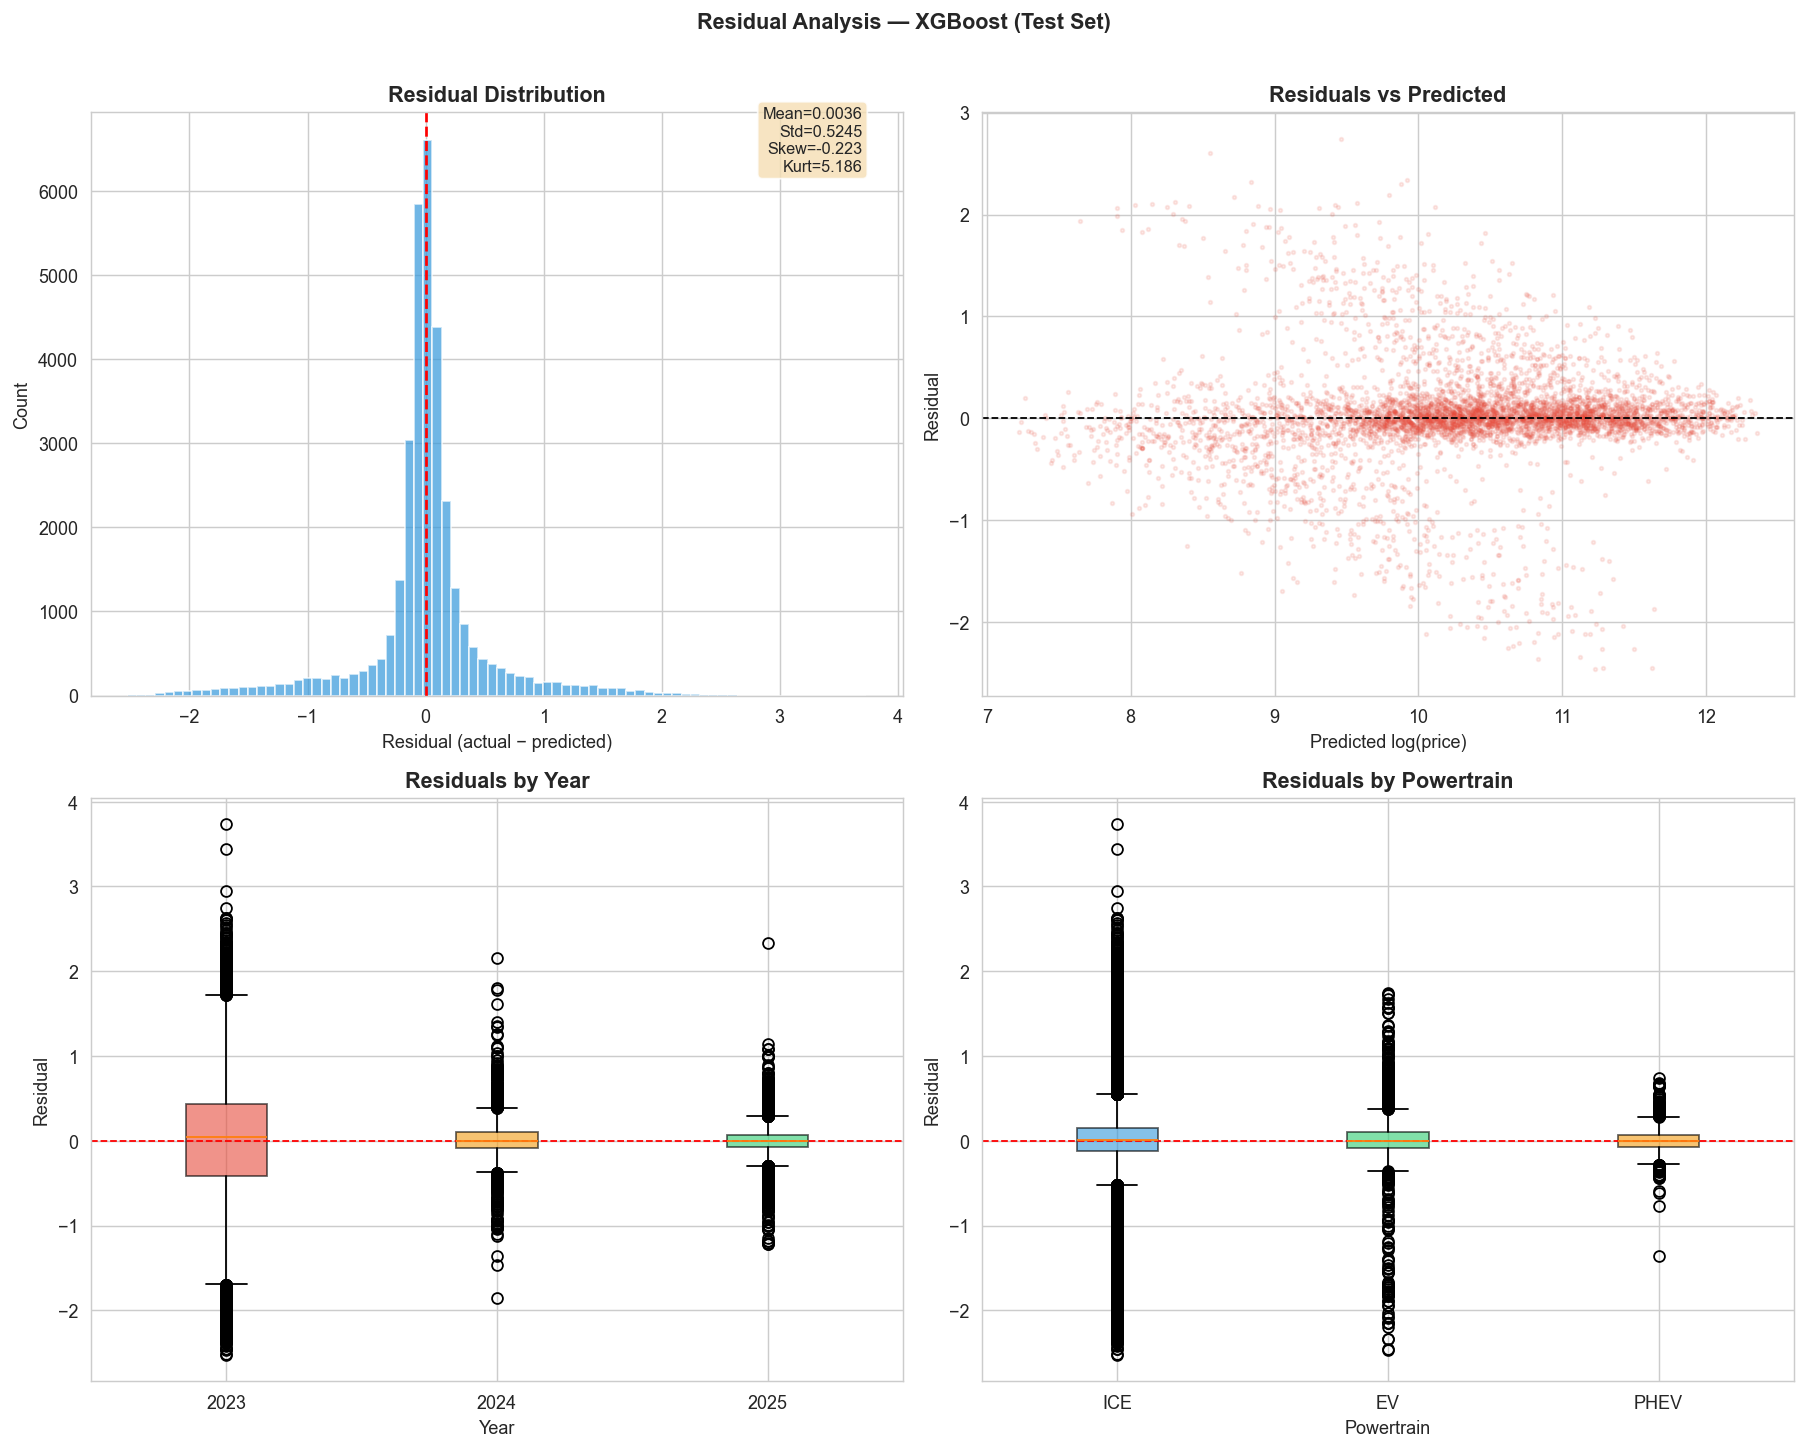

Saved: figures/04_05_residuals.png


In [21]:
best_name = 'XGBoost'
_, pred_best_t = predictions[best_name]
residuals = y_test - pred_best_t

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 15a. Residual distribution
ax = axes[0, 0]
ax.hist(residuals, bins=80, color='#3498db', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', ls='--', lw=1.5)
ax.set_title('Residual Distribution', fontweight='bold')
ax.set_xlabel('Residual (actual \u2212 predicted)')
ax.set_ylabel('Count')
ax.text(0.95, 0.9,
        f'Mean={residuals.mean():.4f}\nStd={residuals.std():.4f}\n'
        f'Skew={pd.Series(residuals).skew():.3f}\nKurt={pd.Series(residuals).kurtosis():.3f}',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 15b. Residuals vs predicted
ax = axes[0, 1]
idx_r = np.random.RandomState(42).choice(len(residuals),
                                          min(5000, len(residuals)), replace=False)
ax.scatter(pred_best_t[idx_r], residuals[idx_r], alpha=0.12, s=4, c='#e74c3c')
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_title('Residuals vs Predicted', fontweight='bold')
ax.set_xlabel('Predicted log(price)')
ax.set_ylabel('Residual')

# 15c. Residuals by year
ax = axes[1, 0]
years_test = df_test['data_year'].values
year_keys = sorted(df_test['data_year'].unique())
res_by_year = [residuals[years_test == yr] for yr in year_keys]
bp = ax.boxplot(res_by_year, labels=[str(y) for y in year_keys], patch_artist=True)
yr_colors = ['#e74c3c', '#f39c12', '#2ecc71']
for patch, color in zip(bp['boxes'], yr_colors[:len(year_keys)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_title('Residuals by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Residual')

# 15d. Residuals by powertrain
ax = axes[1, 1]
pt_test = df_test['powertrain'].values
pt_keys = ['ICE', 'EV', 'PHEV']
res_by_pt = [residuals[pt_test == pt] for pt in pt_keys if (pt_test == pt).sum() > 0]
pt_labels = [pt for pt in pt_keys if (pt_test == pt).sum() > 0]
bp2 = ax.boxplot(res_by_pt, labels=pt_labels, patch_artist=True)
pt_colors = {'ICE': '#3498db', 'EV': '#2ecc71', 'PHEV': '#f39c12'}
for patch, lbl in zip(bp2['boxes'], pt_labels):
    patch.set_facecolor(pt_colors.get(lbl, '#95a5a6'))
    patch.set_alpha(0.6)
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_title('Residuals by Powertrain', fontweight='bold')
ax.set_xlabel('Powertrain')
ax.set_ylabel('Residual')

plt.suptitle(f'Residual Analysis \u2014 {best_name} (Test Set)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '04_05_residuals.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/04_05_residuals.png')

## 16. Leave-One-Year-Out Cross-Validation (LightGBM)

Secondary robustness check: train on 2 years, predict the held-out year.

In [22]:
loyo_results = []
years = sorted(df['data_year'].unique())

for hold_year in years:
    train_years_loyo = [y for y in years if y != hold_year]
    mask_tr = df['data_year'].isin(train_years_loyo)
    mask_te = df['data_year'] == hold_year

    X_lo_tr = df.loc[mask_tr, ml_features].copy()
    X_lo_te = df.loc[mask_te, ml_features].copy()
    y_lo_tr = df.loc[mask_tr, target].values
    y_lo_te = df.loc[mask_te, target].values
    price_lo_te = df.loc[mask_te, TARGET_COL].values

    imp_lo = SimpleImputer(strategy='median')
    X_lo_tr_imp = imp_lo.fit_transform(X_lo_tr)
    X_lo_te_imp = imp_lo.transform(X_lo_te)

    lgb_loyo = lgb.LGBMRegressor(
        **lgb_fitted.best_params_,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    )
    lgb_loyo.fit(X_lo_tr_imp, y_lo_tr)
    pred_lo = lgb_loyo.predict(X_lo_te_imp)

    res = evaluate_model(y_lo_te, pred_lo, price_lo_te, f'LOYO-{hold_year}')
    res['Hold_Year'] = hold_year
    res['Train_Years'] = str(train_years_loyo)
    res['N_train'] = mask_tr.sum()
    res['N_test'] = mask_te.sum()
    loyo_results.append(res)

    print(f'Hold-out {hold_year}:  train={train_years_loyo} ({mask_tr.sum():,}) '
          f'-> test ({mask_te.sum():,})  '
          f'RMSE={res["RMSE_log"]:.4f}  R\u00b2={res["R\u00b2"]:.4f}  '
          f'MAPE={res["MAPE_%"]:.2f}%')

loyo_df = pd.DataFrame(loyo_results)
print('\n--- LOYO Summary ---')
print(loyo_df[['Hold_Year', 'Train_Years', 'N_train', 'N_test',
               'RMSE_log', 'R\u00b2', 'MAPE_%', 'MAE_EUR']].to_string(index=False))

Hold-out 2023:  train=[np.int64(2024), np.int64(2025)] (142,810) -> test (86,060)  RMSE=1.3956  R²=-0.0461  MAPE=12.18%
Hold-out 2024:  train=[np.int64(2023), np.int64(2025)] (193,906) -> test (34,964)  RMSE=0.8522  R²=0.0520  MAPE=6.54%
Hold-out 2025:  train=[np.int64(2023), np.int64(2024)] (121,024) -> test (107,846)  RMSE=0.2921  R²=0.8745  MAPE=2.08%

--- LOYO Summary ---
 Hold_Year                      Train_Years  N_train  N_test  RMSE_log      R²  MAPE_%  MAE_EUR
      2023 [np.int64(2024), np.int64(2025)]   142810   86060    1.3956 -0.0461   12.18    31849
      2024 [np.int64(2023), np.int64(2025)]   193906   34964    0.8522  0.0520    6.54    19289
      2025 [np.int64(2023), np.int64(2024)]   121024  107846    0.2921  0.8745    2.08    11064


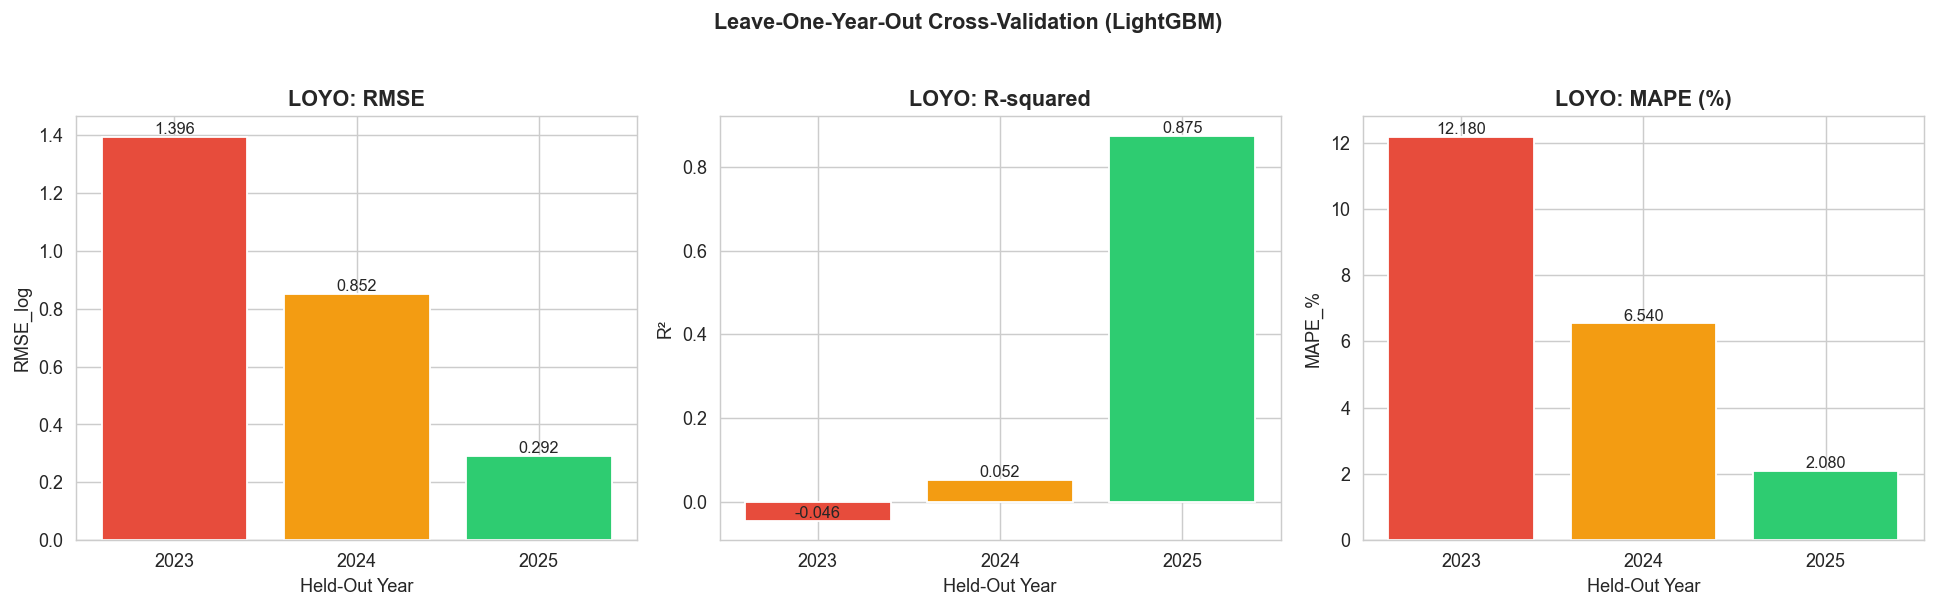

Saved: figures/04_06_loyo_results.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bar_colors = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, metric, title in zip(axes,
                              ['RMSE_log', 'R\u00b2', 'MAPE_%'],
                              ['RMSE', 'R-squared', 'MAPE (%)']):
    bars = ax.bar([str(y) for y in loyo_df['Hold_Year']],
                  loyo_df[metric], color=bar_colors, edgecolor='white')
    ax.set_title(f'LOYO: {title}', fontweight='bold')
    ax.set_xlabel('Held-Out Year')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, loyo_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Leave-One-Year-Out Cross-Validation (LightGBM)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES / '04_06_loyo_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/04_06_loyo_results.png')

## 17. Save Models, Results CSV, and Preprocessors

In [24]:
# Save trained models
for name, model in models_dict.items():
    safe = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    path = MODELS_DIR / f'{safe}_best.pkl'
    joblib.dump(model, path)
    print(f'Saved model: {path.name}')

# Save preprocessors
joblib.dump({'imputer': imputer_ml, 'scaler': scaler_ml},
            MODELS_DIR / 'preprocessor_ml.pkl')
joblib.dump({'imputer': imputer_hed, 'scaler': scaler_hed},
            MODELS_DIR / 'preprocessor_hedonic.pkl')
print('Saved preprocessors.')

# Save results CSV
results_df['evaluation'] = results_df['Split'].str.lower()
results_df.to_csv(DATA_PROC / 'model_results.csv', index=False)
print(f'Saved: model_results.csv ({len(results_df)} rows)')

# Save LOYO results
loyo_df.to_csv(DATA_PROC / 'loyo_results.csv', index=False)
print(f'Saved: loyo_results.csv ({len(loyo_df)} rows)')

# Update feature metadata with best hyperparameters
feat_meta['best_rf']  = rf_fitted.best_params_
feat_meta['best_lgb'] = lgb_fitted.best_params_
feat_meta['best_xgb'] = xgb_fitted.best_params_
with open(DATA_PROC / 'feature_metadata.json', 'w') as f:
    json.dump(feat_meta, f, indent=2, default=str)
print('Updated feature_metadata.json with best hyperparameters.')

print('\n' + '=' * 60)
print('NOTEBOOK 04 COMPLETE')
print('=' * 60)
best_test = test_res.sort_values('RMSE_log').iloc[0]
print(f'Best model: {best_test["Model"]} '
      f'(Test RMSE={best_test["RMSE_log"]:.4f}, '
      f'R\u00b2={best_test["R\u00b2"]:.4f}, '
      f'MAPE={best_test["MAPE_%"]:.2f}%, '
      f'MAE=\u20ac{best_test["MAE_EUR"]:,.0f})')

Saved model: ols_hedonic_best.pkl
Saved model: ridge_best.pkl
Saved model: lasso_best.pkl
Saved model: elasticnet_best.pkl
Saved model: random_forest_best.pkl
Saved model: lightgbm_best.pkl
Saved model: xgboost_best.pkl
Saved preprocessors.
Saved: model_results.csv (18 rows)
Saved: loyo_results.csv (3 rows)
Updated feature_metadata.json with best hyperparameters.

NOTEBOOK 04 COMPLETE
Best model: XGBoost (Test RMSE=0.5245, R²=0.7732, MAPE=3.05%, MAE=€10,048)
